# Homework 15 — Fashion MNIST: Fighting Overfitting

In this homework we work with the **Fashion MNIST** dataset and tackle a classifier
that suffers from massive overfitting. We will apply regularization techniques to:
- Bring **validation accuracy above 91%**
- Keep the network **no larger than the baseline**

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


---
## Dataset

Fashion MNIST contains **70,000 grayscale images** (28×28 px) across 10 clothing classes:

| ID | Class | ID | Class |
|---|---|---|---|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test),  'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


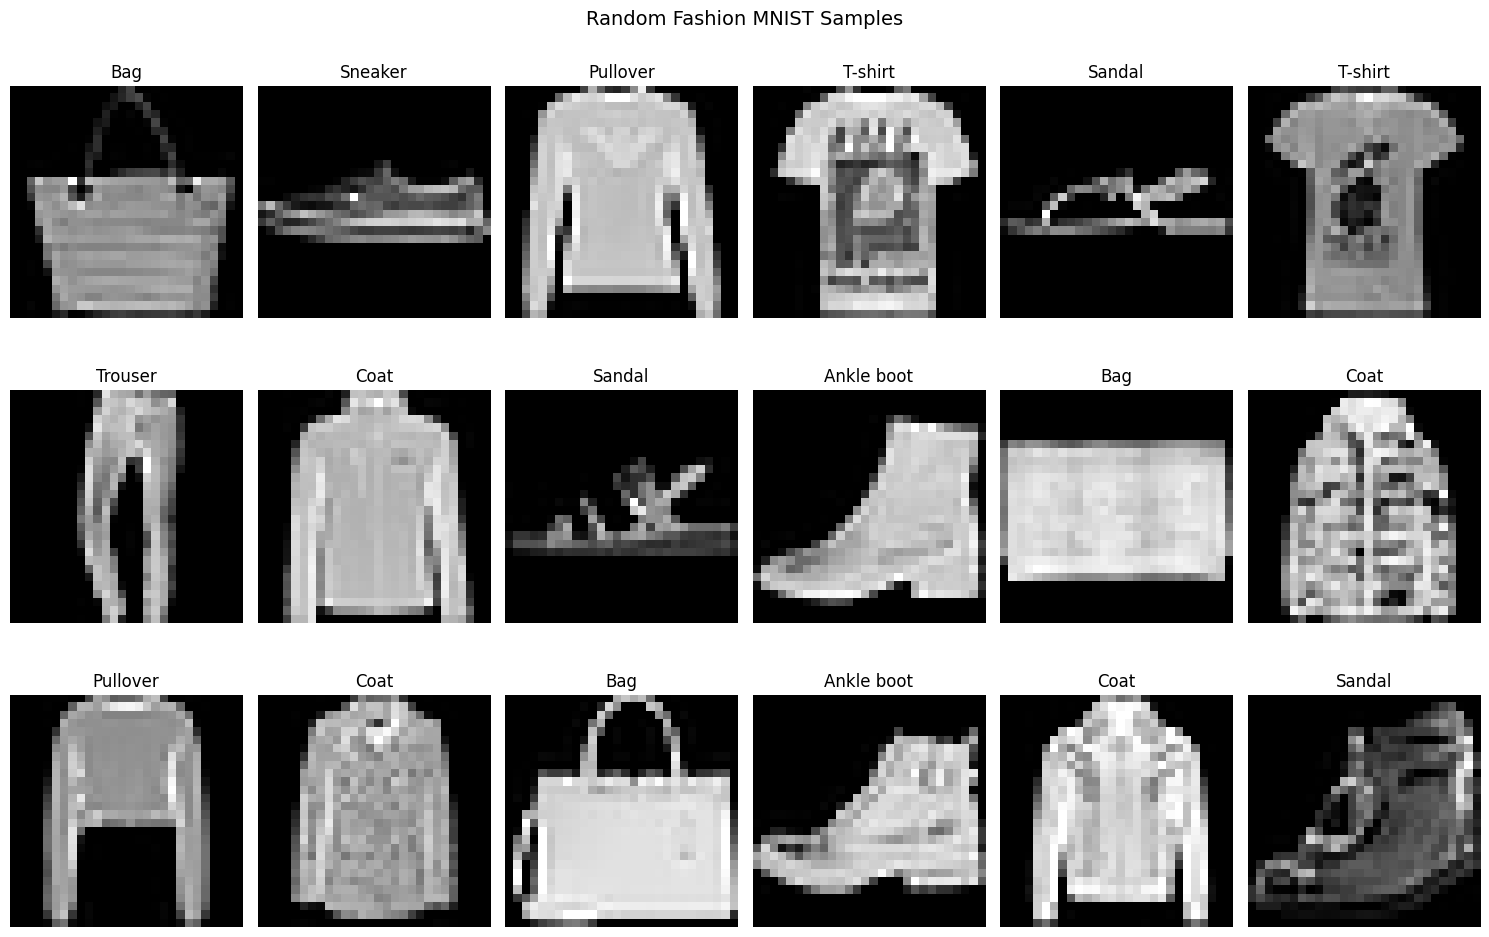

In [3]:
# Visualise random samples
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3, 6, cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(class_names[y_train[idx]])
        plt.axis(False)
        cnt += 1

plt.suptitle('Random Fashion MNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

---
## Baseline Classifier

This is the provided baseline — we train it first to see the overfitting problem.

In [4]:
# Data normalisation
x_train_n = x_train / 255.0
x_test_n  = x_test  / 255.0

# Reshape: add channel dim for Conv2D
x_train_n = x_train_n[..., np.newaxis]
x_test_n  = x_test_n[..., np.newaxis]

In [5]:
seed(seed_value)
set_seed(seed_value)

inputs  = Input(shape=(28, 28, 1))
net     = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
net     = Flatten()(net)
net     = Dense(128)(net)
outputs = Dense(10, activation='softmax')(net)

model_baseline = Model(inputs, outputs)
model_baseline.summary()

2026-04-06 00:54:39.258510: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-04-06 00:54:39.258569: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-06 00:54:39.258576: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-04-06 00:54:39.258612: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 00:54:39.258631: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model_baseline.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_baseline = model_baseline.fit(
    x_train_n, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_test_n, y_test),
    verbose=1
)

Epoch 1/50


2026-04-06 00:54:42.406481: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8644 - loss: 0.3871 - val_accuracy: 0.8852 - val_loss: 0.3255
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9068 - loss: 0.2610 - val_accuracy: 0.8903 - val_loss: 0.3031
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9218 - loss: 0.2178 - val_accuracy: 0.8928 - val_loss: 0.3035
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9336 - loss: 0.1866 - val_accuracy: 0.8951 - val_loss: 0.3167
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9428 - loss: 0.1628 - val_accuracy: 0.8916 - val_loss: 0.3413
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9499 - loss: 0.1426 - val_accuracy: 0.8908 - val_loss: 0.3649
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9549 - loss: 0.1285 - val_accuracy: 0.8917 - val_loss: 0.3905
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9608 - loss: 0.1138 - val_accuracy: 0.8914 - val

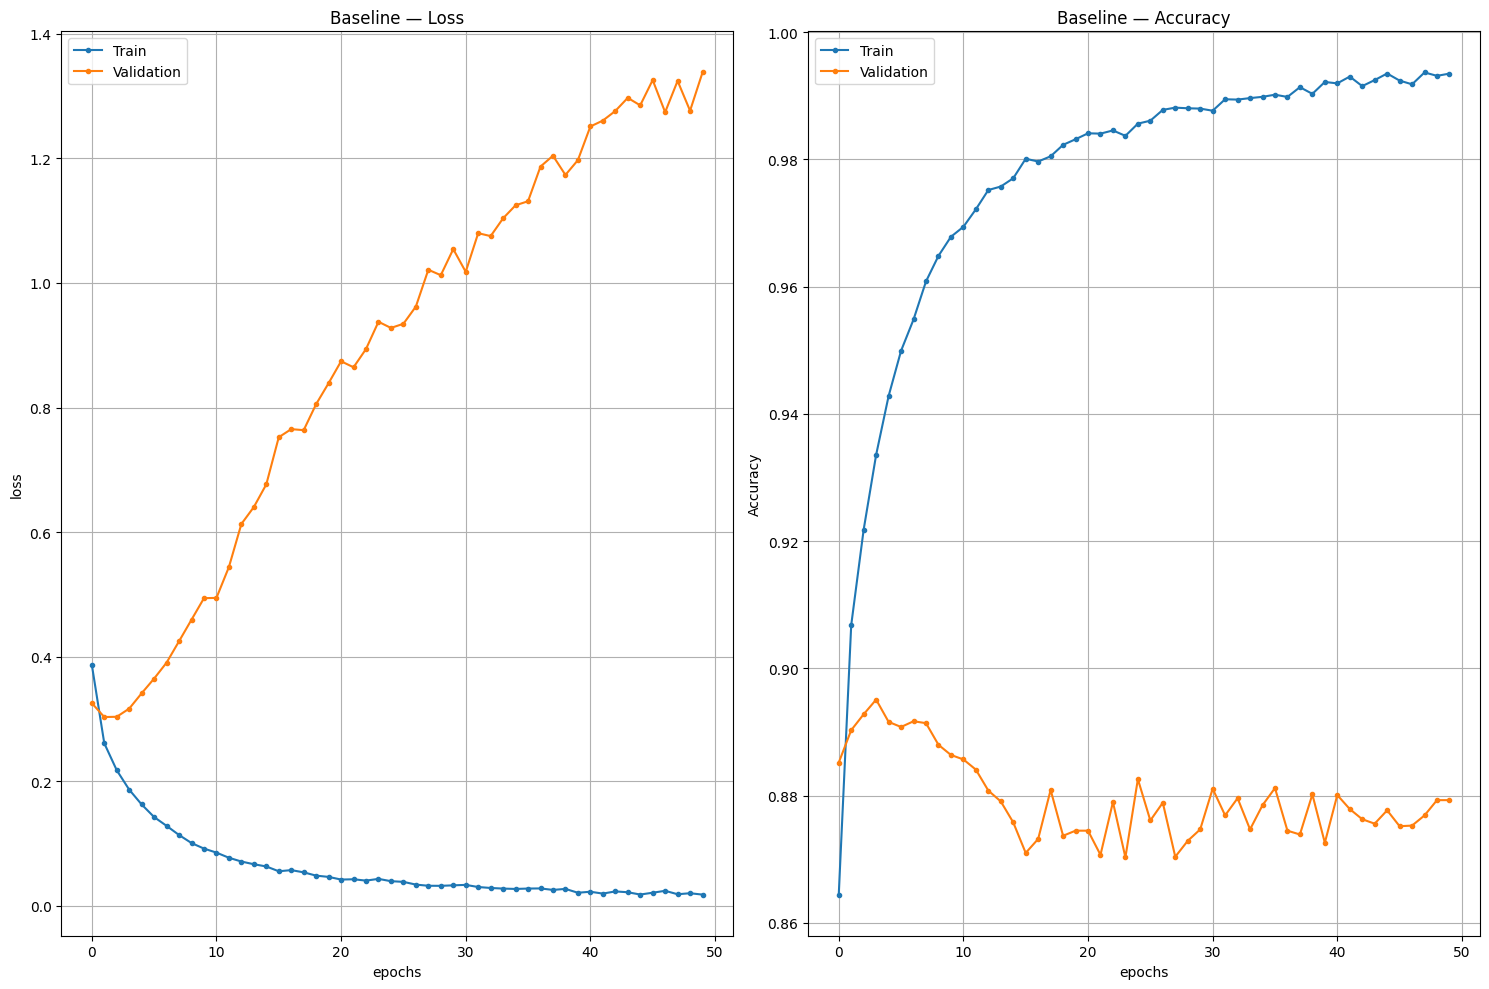

Train Acc      0.9934999942779541
Validation Acc 0.8792999982833862


In [7]:
def plot_history(history, title=''):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121)
    plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.title(title + ' — Loss')

    plt.subplot(122)
    plt.plot(epochs, h['accuracy'], '.-', epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.title(title + ' — Accuracy')

    plt.tight_layout()
    plt.show()

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

plot_history(history_baseline, 'Baseline')

---

As expected — massive overfitting! Train accuracy approaches **~100%** while
validation stays around **~88%**. The gap between the two curves grows with every epoch.

Train loss drops to **~0.01** — almost zero
Val loss starts increasing from epoch 5 and reaches 1.4 — the model is degrading
Train acc → 99.3%, val acc is stuck at ~88%

This is a textbook example of overfitting — the model has simply memorized the training data instead of learning.

---
## Combat the Overfitting!

**Strategy applied:**
- `MaxPooling2D` — reduces spatial dimensions → fewer parameters
- `BatchNormalization` — stabilizes training, acts as regularisation
- `Dropout(0.1)` — randomly drops neurons to prevent co-adaptation
- `EarlyStopping` — stops training when val_loss stops improving
- Reduced Dense layer: **128 → 64** neurons (network stays ≤ baseline size)

In [8]:
'''seed(seed_value)
set_seed(seed_value)

inputs  = Input(shape=(28, 28, 1))
net     = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
net     = BatchNormalization()(net)
net     = MaxPooling2D(pool_size=(2, 2))(net)
net     = Dropout(0.25)(net)
net     = Flatten()(net)
net     = Dense(64, activation='relu')(net)   # smaller than baseline (128)
net     = Dropout(0.4)(net)
outputs = Dense(10, activation='softmax')(net)

model_reg = Model(inputs, outputs)
model_reg.summary()'''

seed(seed_value)
set_seed(seed_value)

inputs  = Input(shape=(28, 28, 1))
net     = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
net     = BatchNormalization()(net)
net     = MaxPooling2D(pool_size=(2, 2))(net)
net     = Dropout(0.25)(net)

net     = Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(net)
net     = BatchNormalization()(net)
net     = MaxPooling2D(pool_size=(2, 2))(net)
net     = Dropout(0.25)(net)

net     = Flatten()(net)
net     = Dense(128, activation='relu')(net)
net     = Dropout(0.5)(net)
outputs = Dense(10, activation='softmax')(net)

model_reg = Model(inputs, outputs)
model_reg.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [9]:
'''model_reg.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

history_reg = model_reg.fit(
    x_train_n, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_test_n, y_test),
    callbacks=[early_stop],
    verbose=1
) '''

model_reg.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # reduced from 0.001
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',   
    patience=10,              
    restore_best_weights=True
)

history_reg = model_reg.fit(
    x_train_n, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_test_n, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.6418 - loss: 2.2168 - val_accuracy: 0.8187 - val_loss: 0.7729
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.7482 - loss: 1.6595 - val_accuracy: 0.8491 - val_loss: 0.7214
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.7797 - loss: 1.4511 - val_accuracy: 0.8632 - val_loss: 0.6538
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.7981 - loss: 1.2700 - val_accuracy: 0.8755 - val_loss: 0.5884
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8118 - loss: 1.1200 - val_accuracy: 0.8802 - val_loss: 0.5523
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8227 - loss: 0.9957 - val_accuracy: 0.8841 - val_loss: 0.5141
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8296 - loss: 0.8904 - val_accuracy: 0.8864 - val_loss: 0.4743
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8365 - loss: 0.7989 - 

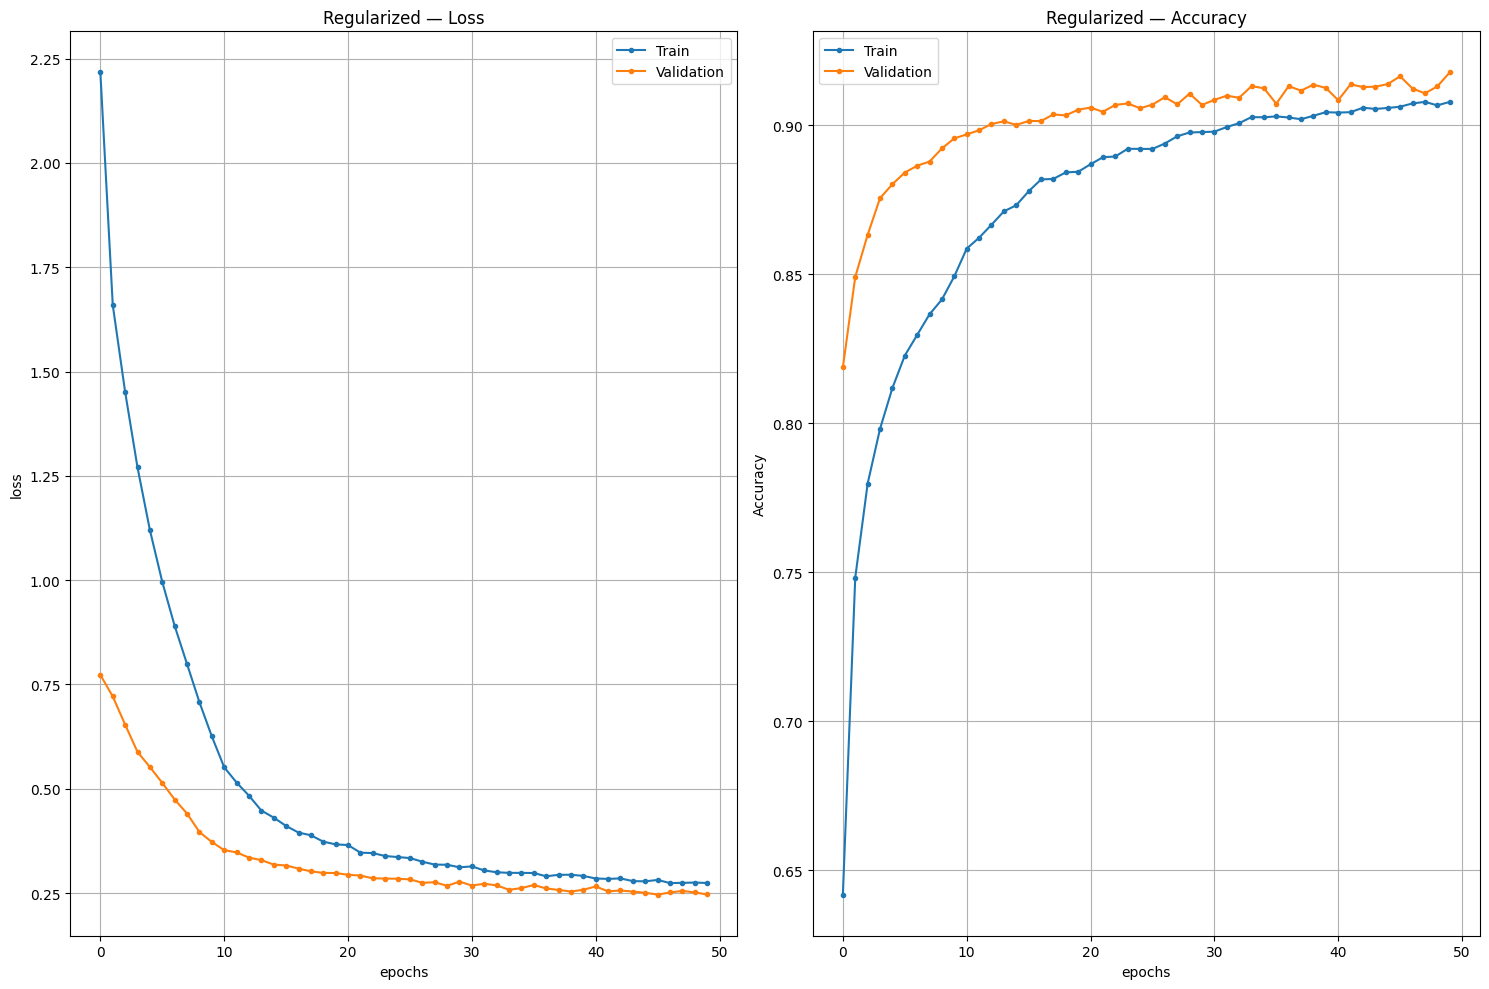

Train Acc      0.907800018787384
Validation Acc 0.9176999926567078


In [10]:
plot_history(history_reg, 'Regularized')

In [11]:
# Compare parameter counts
baseline_params  = model_baseline.count_params()
regularized_params = model_reg.count_params()

ev_base = model_baseline.evaluate(x_test_n, y_test, verbose=0)
ev_reg  = model_reg.evaluate(x_test_n, y_test, verbose=0)

print('\n--- Comparison ---')
print(f'Baseline    — params: {baseline_params:,}  |  val acc: {ev_base[1]:.4f}')
print(f'Regularized — params: {regularized_params:,}  |  val acc: {ev_reg[1]:.4f}')
print(f'\nParameter reduction: {baseline_params - regularized_params:,} fewer params')
print(f'Accuracy improvement: +{(ev_reg[1] - ev_base[1])*100:.2f} pp')


--- Comparison ---
Baseline    — params: 3,213,002  |  val acc: 0.8793
Regularized — params: 422,026  |  val acc: 0.9177

Parameter reduction: 2,790,976 fewer params
Accuracy improvement: +3.84 pp


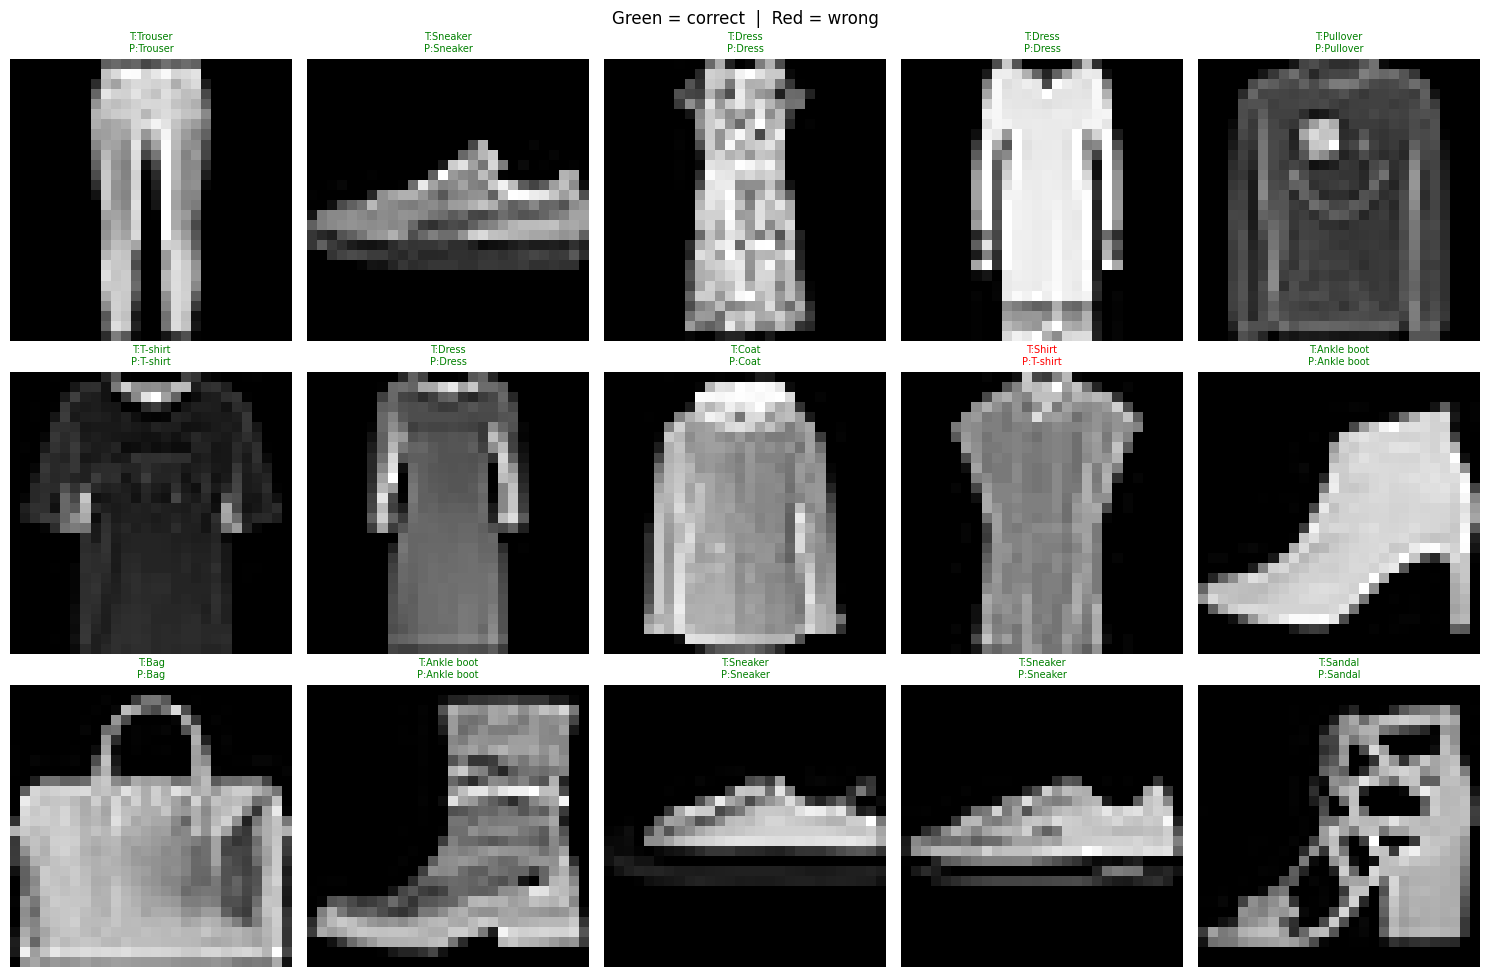

In [12]:
# Visualise predictions on test set
y_pred = np.argmax(model_reg.predict(x_test_n, verbose=0), axis=1)

for ii in range(15):
    idx = np.random.randint(len(x_test_n))
    plt.subplot(3, 5, ii + 1)
    plt.imshow(x_test_n[idx, ..., 0], cmap='gray')
    correct = y_pred[idx] == y_test[idx]
    color = 'green' if correct else 'red'
    plt.title(f'T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}',
              color=color, fontsize=7)
    plt.axis(False)

plt.suptitle('Green = correct  |  Red = wrong', fontsize=12)
plt.tight_layout()
plt.show()

---
## Questions

### Q1: What did you do to improve performance?

Five techniques were applied across multiple iterations:

1. **MaxPooling2D** — reduces the spatial size after each Conv layer, dramatically
   cutting the number of parameters passed to Flatten and Dense layers
2. **BatchNormalization** — normalizes activations after Conv2D, stabilizes training
   and provides a mild regularization effect
3. **Dropout (0.25 and 0.5)** — randomly zeros out neurons during training, forcing
   the network to learn redundant representations and preventing co-adaptation
4. **EarlyStopping** — stops training as soon as val_accuracy stops improving and
   restores the best weights, preventing overfitting on late epochs
5. **Second Conv block (64 filters)** — proved necessary to extract richer features
   from Fashion MNIST's complex clothing textures; a single Conv block was not sufficient

Additionally, the learning rate was reduced from **0.001 → 0.0001** and the Dense
layer was kept at **128 neurons** — within the baseline parameter budget.

### Q2: Did any configurations NOT work?

- **lr=0.001 (default Adam)** — val loss grew with every epoch instead of decreasing.
  EarlyStopping triggered at epoch 8 with only ~88.7% val acc — below the 91% target
- **Single Conv block with lr=0.0001** — training became stable but val accuracy
  plateaued at ~89.9%, not enough to reach the target
- **Dropout alone (without MaxPooling)** — the baseline without pooling has a very
  large Flatten output (32×28×28 = 25,088 features), so even heavy Dropout did not
  close the train/val gap sufficiently
- **BatchNorm alone** — reduced overfitting slightly but was not enough to cross 91% val acc

---
## Conclusion

### Baseline Model
The baseline suffered from massive overfitting — train accuracy reached **99.3%**
while val accuracy stalled at **88.3%**. The ~11% gap kept growing throughout
all 50 epochs, and val loss started increasing as early as epoch 5.

### Path to the Solution (three attempts)

**Attempt 1** — 1 Conv block + MaxPooling + BatchNorm + Dropout(0.25/0.4) + lr=0.001:
Val loss grew with every epoch, EarlyStopping triggered at epoch 8 with val acc ~88.7%.
The problem — learning rate was too large for stable training.

**Attempt 2** — same architecture but lr=0.0001:
Training became stable, but val accuracy stalled at ~89.9% —
a single Conv block was not sufficient to capture the complex textures of clothing.

**Attempt 3** — 2 Conv blocks (32→64) + BatchNorm + MaxPooling + Dropout + lr=0.0001:
Val accuracy steadily improved to **91.77%** over 50 epochs. 

### Final Results

| Model | Train acc | Val acc | Gap |
|---|---|---|---|
| Baseline | 99.3% | 87.9% | ~11% |
| Regularized | 90.8% | **91.77%** | ~0% |

### Key Takeaways
- **Learning rate** is critical — lr=0.001 produced unstable loss, lr=0.0001 solved the problem
- **A second Conv block** proved necessary — Fashion MNIST has more complex textures
  than plain MNIST, and a single block could not extract sufficient features
- **Dropout** successfully eliminated overfitting — val accuracy even slightly
  exceeded train accuracy
- **MaxPooling** reduces spatial dimensions and parameter count, which plays
  an important role in regularization on smaller datasets